## Resampling to adjust (teff, mag, rad, prot) distribution

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import corner
from plotutils import *
from resample import *

import seaborn as sns
sns.set(style='ticks', font_scale=1.6, font='Times New Roman')
plt.rcParams["figure.figsize"] = (10,6)
from matplotlib import rc
rc('text', usetex=True)
import warnings
warnings.filterwarnings("ignore")

In [2]:
lmag = r'\textit{Kepler} magnitude $K_p$'
llogr = '$\log_{10} R$ (ppm)'
figdir = 'figs'

In [3]:
def sample_dkic_pi(dkic):
    piD = dkic.pdet
    idx = np.random.choice(np.arange(len(dkic)), size=len(dkic), p=piD/np.sum(piD))
    dkic_pi = dkic.iloc[idx].reset_index(drop=True)
    return dkic_pi

def get_resampled_kic(dkic_pi, dkoi, teff_bins):
    dkic_smp = sample_near_dkoi(dkic_pi, dkoi, teff_bins, rad_col='lograd')
    return dkic_smp

In [4]:
datadir = '../data_m15/'
dkoi = pd.read_csv(datadir+"m15_koi.csv")
dkic = pd.read_csv("../pdet/m15_kic_w_pdet_TR.csv")

dkicrad = pd.read_csv("../data/DR2PapTable1.txt", delimiter='&')
dkoi = pd.merge(dkoi, dkicrad[['KIC', 'rad']], on='KIC')

dkic['logp'] = np.log10(dkic.Prot)
dkoi['logp'] = np.log10(dkoi.Prot)
dkic['lograd'] = np.log10(dkic.rad)
dkoi['lograd'] = np.log10(dkoi.rad)

### single resampling

In [5]:
dkic_pi = sample_dkic_pi(dkic)

In [6]:
teff_bins = np.arange(3500, 6501, 100)
dkic_smp = get_resampled_kic(dkic_pi, dkoi, teff_bins=teff_bins)

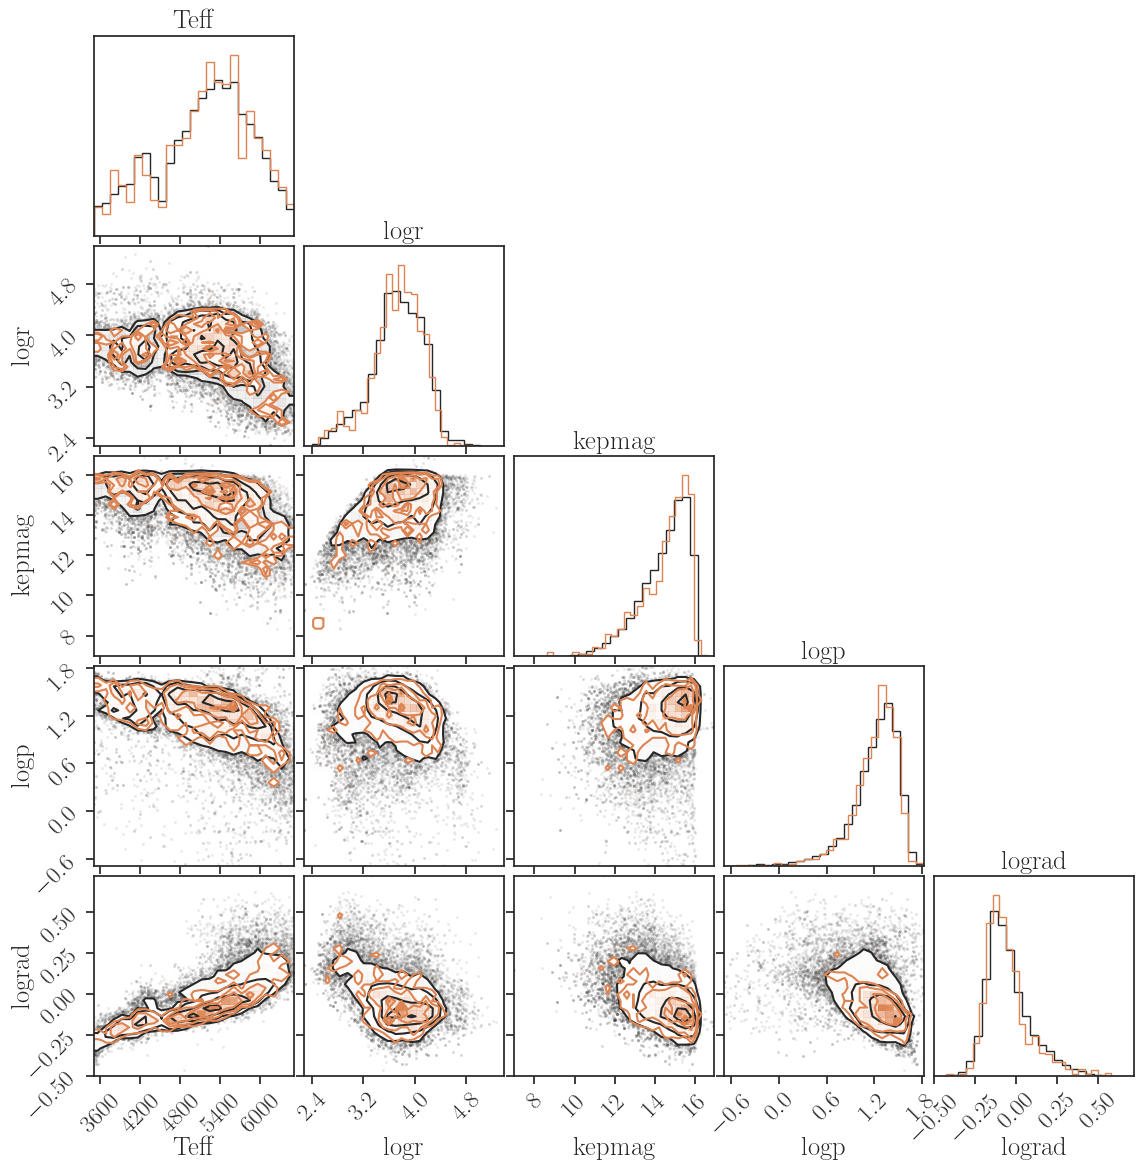

In [7]:
# check
keys = ['Teff', 'logr', 'kepmag', 'logp', 'lograd']
fig = corner.corner(np.array(dkic_pi[keys]), labels=keys, show_titles=True, title_fmt=None, hist_kwargs={'density': True}, bins=25)
_ = corner.corner(np.array(dkic_smp[keys]), labels=keys, show_titles=True, title_fmt=None, hist_kwargs={'density': True}, color='C1', fig=fig, bins=25)

### repeated resampling

In [8]:
dkic_rs_list = []
for i in range(200):
    dkic_pi = sample_dkic_pi(dkic)
    dkic_rs_list.append(get_resampled_kic(dkic_pi, dkoi, teff_bins))

In [9]:
outdir = './'

In [10]:
teff_bins_plot = np.arange(3500, 6501, 150)

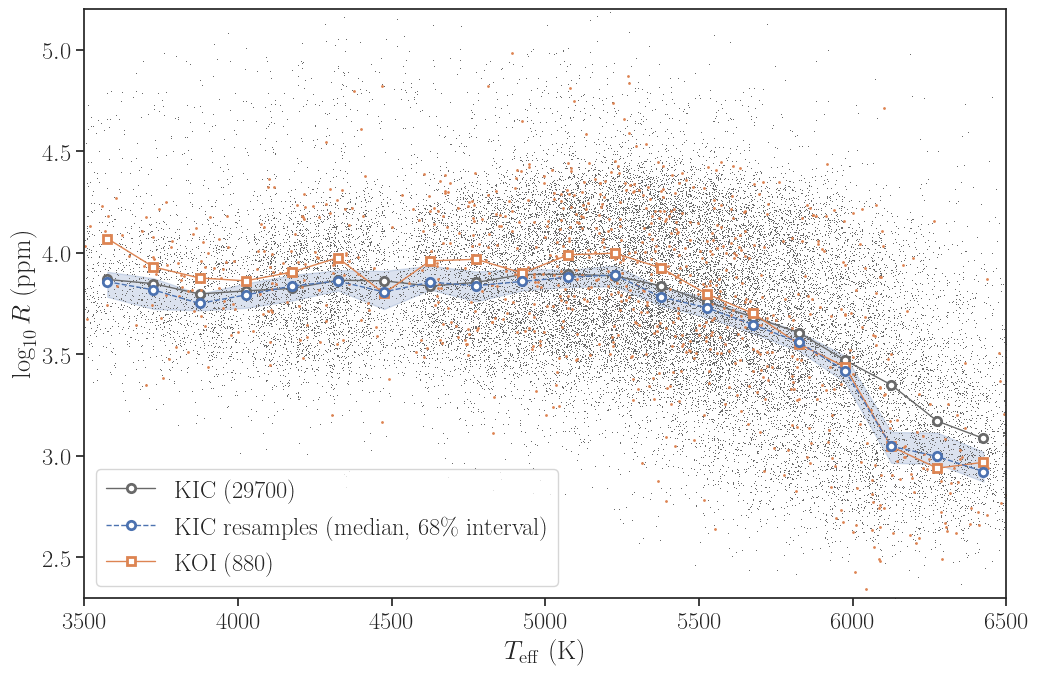

In [12]:
fig = plot_list(dkic, dkoi, dkic_list=dkic_rs_list, teff_bins=teff_bins_plot, figsize=(14*0.85, 9*0.85), label_list='KIC resamples (median, 68\% interval)', ckic='dimgray', ckoi='C1', ckic2='C0')
plt.savefig(outdir+"resample_m15.png", dpi=200, bbox_inches="tight");

### resampling w/o pdet correction

In [12]:
dkic_rs_list = []
for i in range(100):
    dkic_rs_list.append(get_resampled_kic(dkic, dkoi, teff_bins))

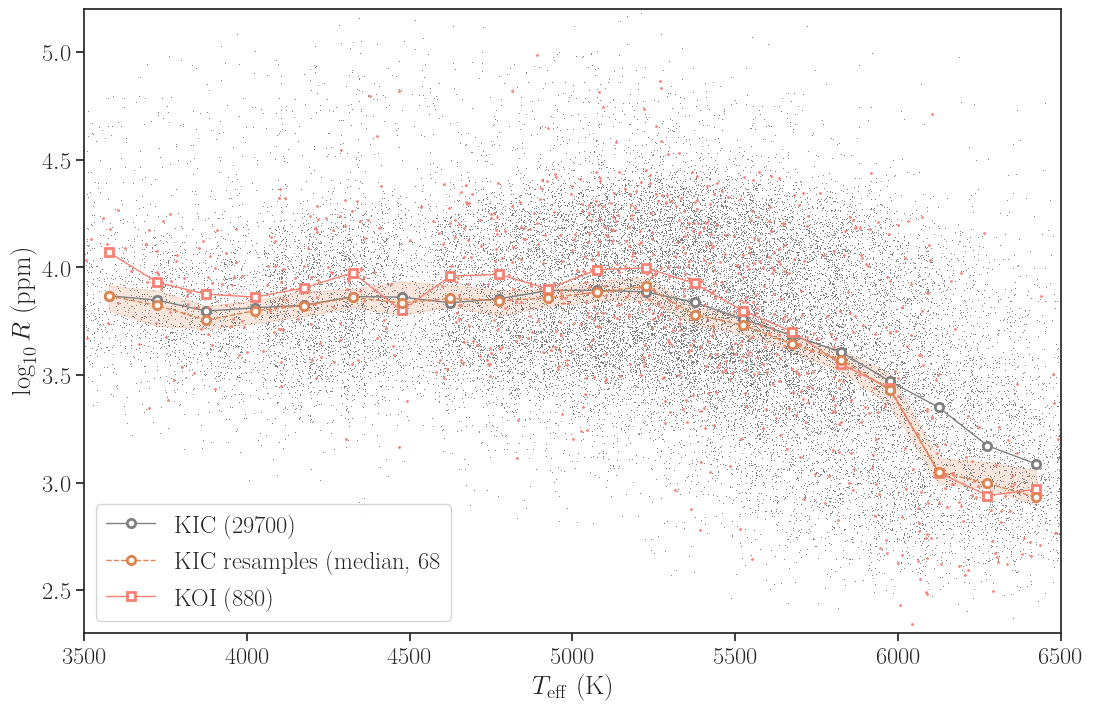

In [13]:
fig = plot_list(dkic, dkoi, dkic_list=dkic_rs_list, teff_bins=teff_bins_plot, figsize=(14*0.9, 9*0.9), 
                label_list='KIC resamples (median, 68% interval)')
plt.savefig(outdir+"resample_m15_wo-pdet.png", dpi=200, bbox_inches="tight")